In [25]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import pandas as pd


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [26]:
# --- Simulation config ---
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000           # number of time steps
DT = T_HORIZON / (T)   # fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [27]:
# --- Data generation ---

translator = {
    'I': 'Current [A]',
    'V': 'Terminal voltage [V]',
    'cn': 'X-averaged negative particle concentration [mol.m-3]',
    'cp': 'X-averaged positive particle concentration [mol.m-3]',
    'cns': 'X-averaged negative particle surface concentration [mol.m-3]',
    'cps': 'X-averaged positive particle surface concentration [mol.m-3]',
    'ocv': 'Battery open-circuit voltage [V]',
}

translator_inv = {v: k for k, v in translator.items()}

data_cols = ['I', 'V', 'ocv']

def gen_cols(data_cols, translator=translator):
    '''Extracting variable names from translator dict for given data_cols'''
    return [translator[col] for col in data_cols]



def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

def observe_states(t_query, sol, model, data_cols):
    data = pd.DataFrame(index=t_query)
    cols = gen_cols(data_cols)
    for col in cols:
        data[translator_inv[col]] = sol.observe(model.variables[col])(t_query)
    return data

def get_vals_DC(I0,data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_pulse(data_cols=data_cols):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_GRF(data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model


def gen_data(B, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    '''Generate trajectories with shape (B, T, D)'''

    rng = np.random.default_rng(seed)

    dot_cols = [f"{k}_dot" for k in data_cols if k in ['cn','cp']]
    all_cols = data_cols + ['dI'] + dot_cols + ['valid']

    D = len(all_cols)

    X = np.zeros((B, T, D))
    var_index = {k:i for i,k in enumerate(all_cols)}

    for b in trange(B):

        if currents == 'DC':
            data, valid_b, param, sol, model = get_vals_DC(float(rng.uniform(I_low, I_high)))
        elif currents == 'pulse':
            data, valid_b, param, sol, model = get_vals_pulse()
        elif currents == 'GRF':
            data, valid_b, param, sol, model = get_vals_GRF()
        else:
            raise ValueError("Invalid current type")

        # base variables
        for col in data_cols:
            X[b, :, var_index[col]] = data[col].values

        # dI
        if 'I' in data_cols:
            I = data['I'].values
            dI = np.zeros_like(I)
            dI[1:] = np.diff(I)
            X[b, :, var_index['dI']] = dI

        # derivatives
        for col in ['cn','cp']:
            if col in data_cols:
                x = data[col].values
                xdot = np.zeros_like(x)
                xdot[:-1] = np.diff(x) / DT
                xdot[-1] = xdot[-2]
                X[b, :, var_index[f"{col}_dot"]] = xdot

        # valid mask
        X[b, :, var_index['valid']] = valid_b.astype(float)

    return X, var_index


In [28]:
X, var_index = gen_data(2, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=42)
print("Data shape:", X.shape)
print("Variable index:", var_index)

100%|██████████| 2/2 [00:02<00:00,  1.35s/it]

Data shape: (2, 1000, 5)
Variable index: {'I': 0, 'V': 1, 'ocv': 2, 'dI': 3, 'valid': 4}


In [119]:
# --- Load data ---
def load_data(path, var_index = var_index):
    with np.load(path) as d:
        X = d['X']  # replace 'X' with the actual key if different

    data = {var: X[:, :, idx] for var, idx in var_index.items()}
    return data


path = f'data_PHNN/data_c_pulse_dt_{T}.npz'
D = load_data(path)
I = D['I']; V = D['V']; ocv = D['ocv']
B = I.shape[0]

D['valid'] = D['valid'].astype(bool)

In [120]:
# --- Normalization ---
stats = {}
def compute_stats(D=D,data_cols=data_cols):
    for name in data_cols:
        stats[name] = (float(D[name].ravel()[D['valid'].ravel()].mean()), float(max(D[name].ravel()[D['valid'].ravel()].std(), 1e-8)))  # Avoid zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = compute_stats()

# Normalize

I_n = transform(I, 'I')
V_n = transform(V, 'V')
ocv_n = transform(ocv, 'ocv')

In [121]:
# --- Split data ---
x = torch.tensor(np.stack([I_n], axis=-1), dtype=torch.float32) # (B, T, 4)
print(x.shape)
y = torch.tensor(np.stack([V_n, ocv_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(D['valid'], dtype=torch.float32)

split = int(0.8 * B)
def _split(arr):
    return arr[:split], arr[split:]

def _split_flat(arr):
    return arr[:split].flatten(0,1), arr[split:].flatten(0,1)   # Same as reshape(B * T, C)    # (B*T, 4)

# Flatten time dimension for training and split
x_train, x_test = _split_flat(x)        
y_train, y_test = _split_flat(y)
mask_train, mask_test = _split_flat(mask)

# # Unflattened
x_train_batch, x_test_batch = _split(x) # (B, T, 4)
y_train_batch, y_test_batch = _split(y)
mask_train_batch, mask_test_batch = _split(mask)

# Un-normalized for plotting
I_train,      I_test      = _split(I)
V_train,      V_test      = _split(V)
ocv_train,    ocv_test    = _split(ocv)
mask_train_plot, mask_test_plot = _split(D['valid'])

batch_size_small = int(B/4)
# batch_size_large = int(B*T/4)
train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
# train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

torch.Size([100, 1000, 1])


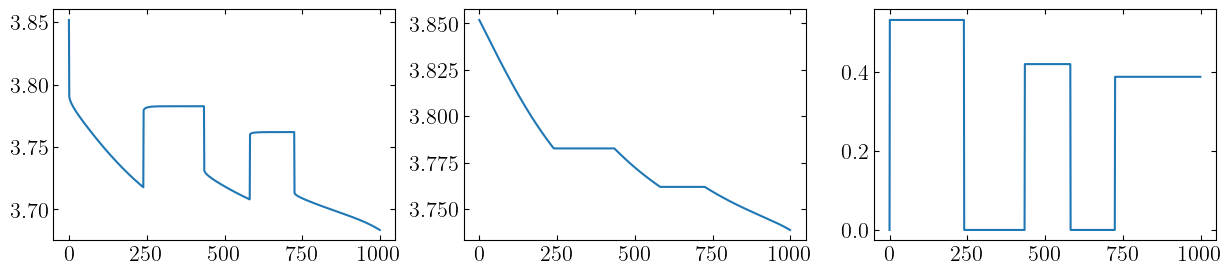

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(V_test[0, :], label='cn')
axes[1].plot(ocv_test[0, :], label='valid')
axes[2].plot(I_test[0, :], label='dI')


In [ ]:
# Parameter identification via gradient descent
class BatteryPHNN_SOC(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        # SOC in [0,1] → 3 positive parameters
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )
        self.R1 = nn.Parameter(torch.tensor(0.1))
        self.R0 = nn.Parameter(torch.tensor(.1))
        self.C1 = nn.Parameter(torch.tensor(100.))
    # @property
    # def R0(self):
    #     return torch.nn.functional.softplus(self.R0_raw)

    # @property
    # def R1(self):
    #     return torch.nn.functional.softplus(self.R1_raw)

    # @property
    # def C1(self):
    #     return torch.nn.functional.softplus(self.C1_raw)

    def forward(self, x):
        # soc: (B,) or (B, 1)
        return nn.functional.softplus(self.net(x))   # (B, 3)

model = BatteryPHNN_SOC()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

def dH_dx(pred, X):
    H = pred # Number of parameters predicted by the model, e.g. 3 for R0, R1, C1
    dQ = torch.autograd.grad(H, X,grad_outputs=torch.ones_like(H), create_graph=True)[0][:,0]
    dq1 = torch.sqrt(torch.clamp(2 * pred / model.C1, min=1e-8)).squeeze(1)
    
    return torch.stack([dQ, dq1], dim=1)

def dynamics(pred, X, I_t):

    dH_dq = dH_dx(pred,X)[:, 1]  # Assuming q1 is the second state variable in X
    #dH_dq = torch.sqrt(2 * pred / model.C1)
    dq1 = I_t - dH_dq / abs(model.R1)
    dQ = - I_t
    return torch.stack([dQ, dq1], dim=1)


def Euler_evolver(pred, x, I_t, dt):
    '''
    x   : (B, 2)   [Q, q1]
    I_t : (B,)     current [A]
    dt  : float
    '''
    dX = dynamics(pred, x, I_t)  # (B, 2)
    return x + dX * dt            # Euler update

# def evolver(pred, x, I_t, dt):
#     '''
#     x   : (B, 2)   [Q, q1]
#     I_t : (B,)     current [A]
#     dt  : float
#     '''

#     # Q update — explicit (I does not depend on Q)
#     Q_new  = Q - I_t * dt

#     # q1 update — implicit, closed form, unconditionally stable
#     tau    = R1 * C1                   # scalar, RC time constant
#     q1_new = (q1 + dt * I_t) / (1.0 + dt / tau)   # (B,)
#     return torch.stack([Q_new, q1_new], dim=1)     # (B, 2)


def ph_rollout(model, x0, I_phys, ocv_phys, dt, evalu = True):
    """
    x0    : (B, 2)   [Q0 in Coulombs, q1_0=0]
    Q_0   : (B,)     initial charge, e.g. from coulomb counting or assumed full
    """
    x = x0
    B_b, T_steps = I_phys.shape
    V_pred = []
    C1 = []

    for t in range(T_steps):
        I_t   = I_phys[:, t]         # (B,)
        ocv_t = ocv_phys[:, t]       # (B,)
        H_pred = model(x)  # (B, H)   Predict parameters from SOC
        V_t = ocv_t - dH_dx(H_pred,x)[:, 1] - abs(model.R0) * I_t  # (B,)     Compute voltage from OCV and q1
        V_pred.append(V_t)
        C1.append(2 * H_pred / dH_dx(H_pred,x)[:, 1]**2) 
        x = Euler_evolver(H_pred, x, I_t, dt)  
    if evalu:
        return torch.stack(V_pred, dim=1), C1
    else:    
        return torch.stack(V_pred, dim=1)  



def masked_mse(pred, target, mask):
    err = (pred - target) ** 2    # (B, T)
    return (err * mask).sum() / (mask.sum() * 2)

def training(epochs=10):
    history = {"loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        start_t = time.perf_counter()

        for x_b, y_b, mask_b in train_loader_batch:
            B_b = x_b.shape[0]
            x0 = torch.zeros(B_b, 2).requires_grad_(True)  # Initial states

            I_phys   = x_b[:, :, 0] * stats['I'][1] + stats['I'][0]         # Denormalize current (B, T)
            ocv_phys = y_b[:, :, 1] * stats['ocv'][1] + stats['ocv'][0]     # Denormalize OCV
            V_true_n = y_b[:, :, 0]                                         # Normalized voltage

            V_pred,C = ph_rollout(model, x0, I_phys, ocv_phys, dt=DT,evalu=True)     # (B, T)
            V_pred_n = (V_pred - stats['V'][0]) / stats['V'][1]         # Normalize predicted voltage

            # print(V_pred_n[0, :10], V_true_n[0, :10], mask_b[0, :10])

            loss = masked_mse(V_pred_n, V_true_n, mask_b)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tot_ep_loss += loss.item()

        avg_loss = tot_ep_loss / len(train_loader_batch)  # Average loss per batch
        end_t = time.perf_counter()

        history["loss"].append(avg_loss)
        #history["p_loss"].append(p_last)
        history["time per ep"].append(end_t - start_t)
        print(f"Epoch {ep+1} | loss {avg_loss:.3e} | time {end_t - start_t:.2f}s")

    return history
    

In [154]:
history = training(epochs=15)

Epoch 1 | loss 6.514e+00 | time 3.35s
Epoch 2 | loss 6.384e+00 | time 3.48s
Epoch 3 | loss 5.683e+00 | time 3.44s
Epoch 4 | loss 5.926e+00 | time 3.33s
Epoch 5 | loss 5.422e+00 | time 3.47s
Epoch 6 | loss 4.980e+00 | time 3.34s
Epoch 7 | loss 5.029e+00 | time 3.46s
Epoch 8 | loss 4.363e+00 | time 3.33s


KeyboardInterrupt: 

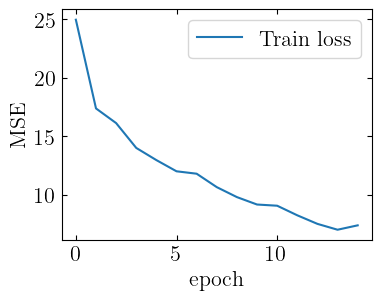

In [149]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend();

In [152]:
def eval_rollout_phnn(idx=0):
    model.eval()
    x_seq = x_test_batch
    y_seq = y_test_batch
    m_seq = mask_test_batch
    V_seq = V_test


    x_b  = x_seq[idx:idx+1]            # (1, T, 1)
    y_b  = y_seq[idx:idx+1]            # (1, T, 2)

    I_phys   = x_b[:, :, 0] * stats['I'][1] + stats['I'][0]         # Denormalize current (1, T)
    ocv_phys = y_b[:, :, 1] * stats['ocv'][1] + stats['ocv'][0]     # Denormalize OCV

    x0 = torch.zeros(1, 2).requires_grad_(True)  # Initial states
    V_pred_phys, C = ph_rollout(model, x0, I_phys, ocv_phys, dt=DT, evalu=True)     # (1, T)

    V_pred = V_pred_phys.squeeze(0).detach().numpy()     # (T,)
    V_true = V_seq[idx]                         # (T,)
    valid  = m_seq[idx].numpy().astype(bool)    # (T,)
    t      = np.arange(x_seq.shape[1]) * DT
    
    return V_pred, V_true, I_phys, t, valid,C

0.5068507194519043 0.7057248950004578 100.1756820678711


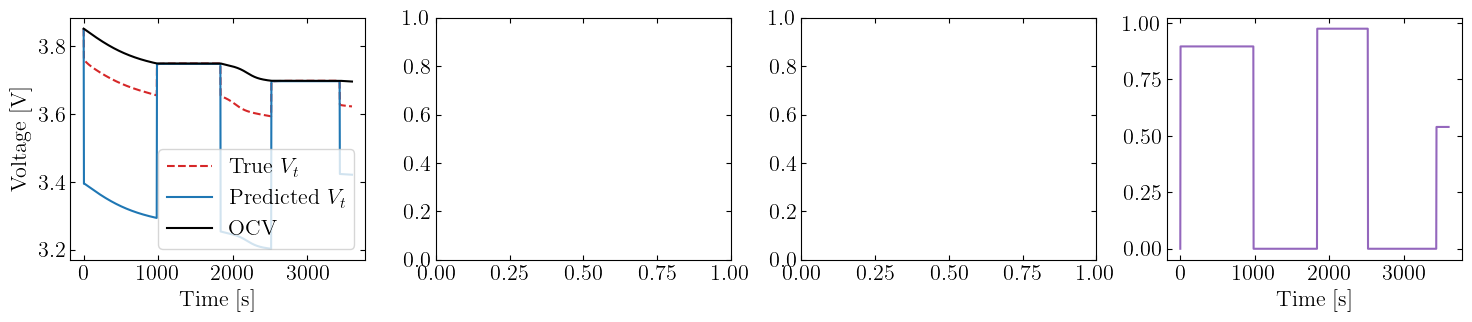

In [153]:
idx = 12
V_pred, V_true, I_phys,t_plot, valid,C = eval_rollout_phnn(idx)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))

axes[0].plot(t_plot[valid], V_true[valid], '--', color = 'tab:red', label=r'True $V_t$')
axes[0].plot(t_plot[valid], V_pred[valid], color = 'tab:blue',  label=r'Predicted $V_t$')
axes[0].plot(t_plot[valid], ocv_test[idx][valid], 'k-', label=r'OCV')
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Voltage [V]")
axes[0].legend()

print(model.R0.item(), model.R1.item(), C[-1][0].item())

axes[3].plot(t_plot, I_phys[0, :], color='tab:purple', label=r'RC time constant $\tau$ [s]')
axes[3].set_xlabel("Time [s]")

fig.tight_layout()